In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# **1. Carga  y limpieza de datos**

In [51]:
df= pd.read_csv('../Data/Historical Product Demand.csv')


In [52]:
df.head()

,Product_Code,Warehouse,Product_Category,Date,Order_Demand
0,Product_0993,Whse_J,Category_028,2012/7/27,100
1,Product_0979,Whse_J,Category_028,2012/1/19,500
2,Product_0979,Whse_J,Category_028,2012/2/3,500
3,Product_0979,Whse_J,Category_028,2012/2/9,500
4,Product_0979,Whse_J,Category_028,2012/3/2,500


In [53]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 5 columns):
 #   Column            Non-Null Count    Dtype 
---  ------            --------------    ----- 
 0   Product_Code      1048575 non-null  object
 1   Warehouse         1048575 non-null  object
 2   Product_Category  1048575 non-null  object
 3   Date              1037336 non-null  object
 4   Order_Demand      1048575 non-null  object
dtypes: object(5)
memory usage: 40.0+ MB


🔥 **INSIGHT** 
- Las fechas estan en formato incorrecto
- Existen nulos en card (?)

## Revision datos nulos

In [54]:
df.isnull().sum()

Product_Code            0
Warehouse               0
Product_Category        0
Date                11239
Order_Demand            0
dtype: int64

In [55]:
print(f'La cantidad de nulos es {np.max(df.isnull().sum().values)} y el dataframe tiene {df.shape[0]}')

La cantidad de nulos es 11239 y el dataframe tiene 1048575


- En este caso debido a que la cantidad de nulos que representa casi un 1.1 % del total de los datos es correcto eliminarlos

In [56]:
df.dropna(subset=['Date'], inplace=True)

- Existen bastantes nulos los que eliminaremos
- Además también existen otros carácteres que no son números

# **2.  Análisis exploratorio (EDA)**

## Revisando las variables categoricas y numericas si existen problemas

In [57]:
for col in df[['Product_Code', 'Warehouse', 'Order_Demand']].columns:

    print(df[col].unique)

<bound method Series.unique of 0          Product_0993
1          Product_0979
2          Product_0979
3          Product_0979
4          Product_0979
               ...     
1048570    Product_1791
1048571    Product_1974
1048572    Product_1787
1048573    Product_0901
1048574    Product_0704
Name: Product_Code, Length: 1037336, dtype: object>
<bound method Series.unique of 0          Whse_J
1          Whse_J
2          Whse_J
3          Whse_J
4          Whse_J
            ...  
1048570    Whse_J
1048571    Whse_J
1048572    Whse_J
1048573    Whse_J
1048574    Whse_J
Name: Warehouse, Length: 1037336, dtype: object>
<bound method Series.unique of 0           100 
1           500 
2           500 
3           500 
4           500 
           ...  
1048570    1000 
1048571       1 
1048572    2500 
1048573      50 
1048574       4 
Name: Order_Demand, Length: 1037336, dtype: object>


- La única columna que se ve con problemas seria `Order_demand` la que no es numérica y además tiene carácteres como paréntesis

### Eliminando los datos que no sean numeros de la columna order_demand

In [58]:
df['Order_Demand'] = df['Order_Demand'].str.replace(r'[^0-9]', '', regex=True).astype(int)


- Aprovechamos de después de sacar todos los datos no numericos convertir a integer, si está bien entonces no deberia tirar error.

In [59]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1037336 entries, 0 to 1048574
Data columns (total 5 columns):
 #   Column            Non-Null Count    Dtype 
---  ------            --------------    ----- 
 0   Product_Code      1037336 non-null  object
 1   Warehouse         1037336 non-null  object
 2   Product_Category  1037336 non-null  object
 3   Date              1037336 non-null  object
 4   Order_Demand      1037336 non-null  int32 
dtypes: int32(1), object(4)
memory usage: 43.5+ MB


## Convirtiendo Date a datetime

In [60]:
df['Date'] = pd.to_datetime(df['Date'])

In [61]:
df.set_index('Date', inplace=True)

## Revisando los estadisticos

In [62]:
df.describe().round(2)

,Order_Demand
count,1037336.00
mean,4949.38
std,29073.44
min,0.00
25%,20.00
50%,300.00
75%,2000.00
max,4000000.00


- Existen datos donde no hay ordenes lo que sugiere que fueron dias donde no se vendió nada.
- El 75 % de los datos se encuentra por debajo de 2000 ordenes pero el valor máximo es de 4000000 lo que es 1999 veces más grande
- En este punto no podriamos ver bien la distribucion ya que por este valor la diferencia de escalas no dejara revisar bien su distribución
     

## Revisando los valores de Order_Demand

C:\Users\kev_g\AppData\Local\Temp\ipykernel_25428\819333884.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(df['Order_Demand'], palette='pastel')


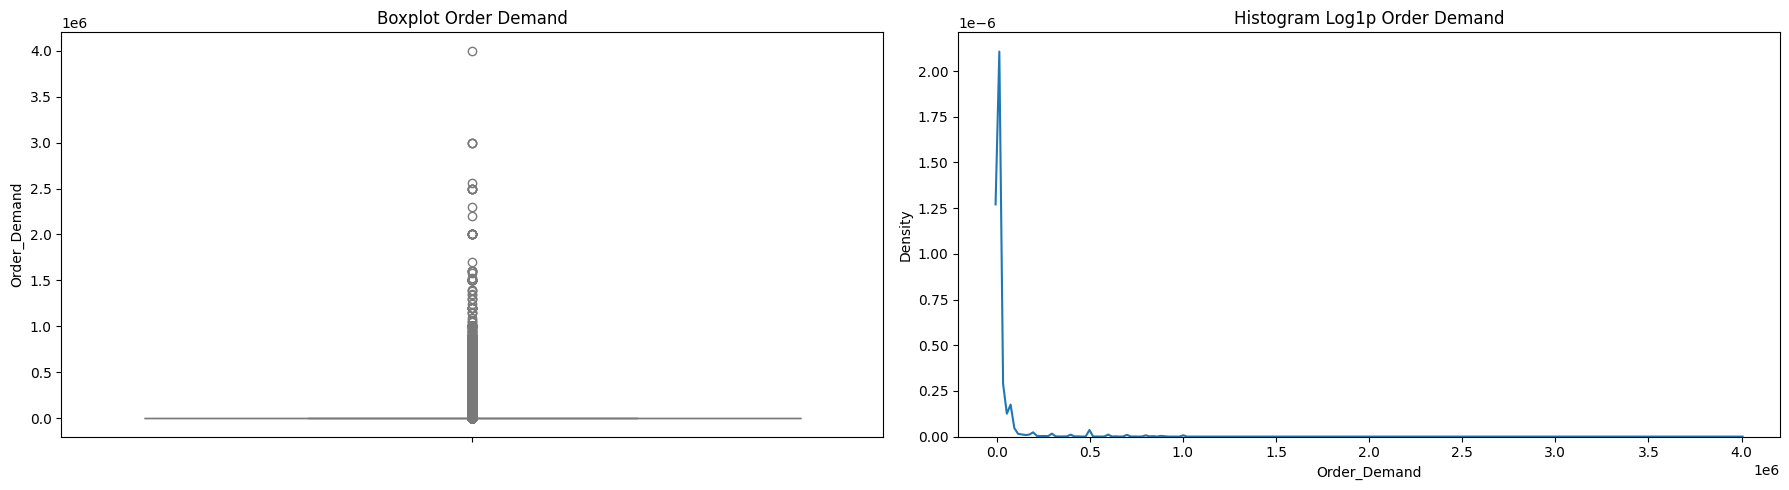

In [63]:
plt.figure(figsize=(18, 5)) 
plt.subplot(121)
sns.boxplot(df['Order_Demand'], palette='pastel')
plt.title('Boxplot Order Demand')

plt.subplot(122)
sns.kdeplot(df['Order_Demand'])
plt.title('Histogram Log1p Order Demand')


plt.tight_layout()
plt.show()

🔎 **Análisis gráficos.**

#### **_Boxplot_**

En este gráfico queda claro la gran diversidad de escalas en los datos desde 0 hasta los millones por lo que no podemos ver claramente que pasa con nuestros datos. Esto impide observar de manera clara la estructura central de nuestros datos y su respectiva dispersión, principalmente porque los valores extremos dominan visualmente el gráfico.


#### **_KDE PLOT_**

El kdeplot viene a confirmar que nuestra distribución esta sesgada a la derecha (**right skew**), típica de una distribución log normal. La gran cantidad de los valores bajos a la izquierda y una larga cola a la derecha refuerzan esto.

🎓 **Conclusión**:

Nuestros datos son candidatos para aplicar una transformación logaritmica. Esto es debido a que si bien los modelos de Forecast pueden pasarse con los datos sin un tratado considerando estos datos que tenemos nos veremos beneficiados en los siguientes puntos.

 - Reducir la varianza y asimetría de la distribución
 - Mejorar el desempeño de los modelos

## **CONVERSION order_demand a log1p**

In [64]:

df['Order_Demand_log'] = np.log1p(df['Order_Demand'])   

C:\Users\kev_g\AppData\Local\Temp\ipykernel_25428\776211089.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(df['Order_Demand_log'], palette='pastel')


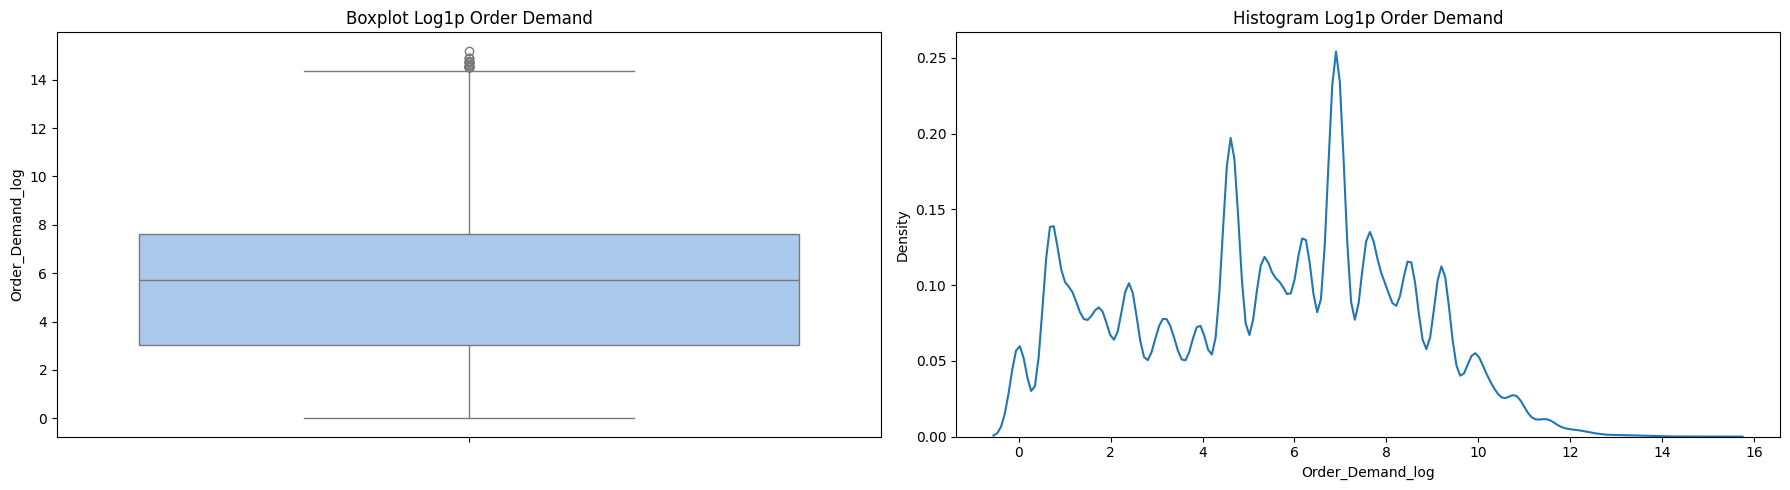

In [65]:
plt.figure(figsize=(18, 5)) 

plt.subplot(121)
sns.boxplot(df['Order_Demand_log'], palette='pastel')
plt.title('Boxplot Log1p Order Demand')

plt.subplot(122)
sns.kdeplot(df['Order_Demand_log'])
plt.title('Histogram Log1p Order Demand')

plt.tight_layout()
plt.show()


🆗 Como es notorio en los gráficos superiores la transformación logaritmica a ayudado a nuestra variable objetivo a tener una distribución más simetrica y también a mostrarnos de mejor manera la estructura de su distribución observada en el boxplots.



# **OBSERVANDO LA SERIE TEMPORAL**

<Axes: title={'center': 'Demanda vs tiempo'}, xlabel='Date'>

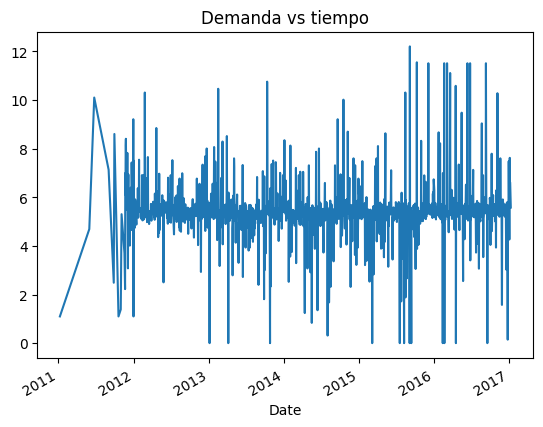

In [66]:
df.groupby(df.index)['Order_Demand_log'].mean().plot(kind='line', title='Demanda vs tiempo')

📉
- Lo primero que se observa que antes desde el 2011 hasta principio del 2012 los datos no son representativos de la mayor parte de nuestro universo

- En general se puede observar que en promedio los datos se encuentran bastante centrados cerca del 6 - 4.


🎓 **Conclusión**:

Teniendo en consideración este gráfico modelare desde el 2012 en adelante

# **DEFINIENDO LA VARIABLE OBJETIVO**

In [67]:
y = df['Order_Demand_log'].resample('W-MON').mean()


In [68]:
y = y.ffill()

In [69]:
y = y[(y.index.year >2012)]


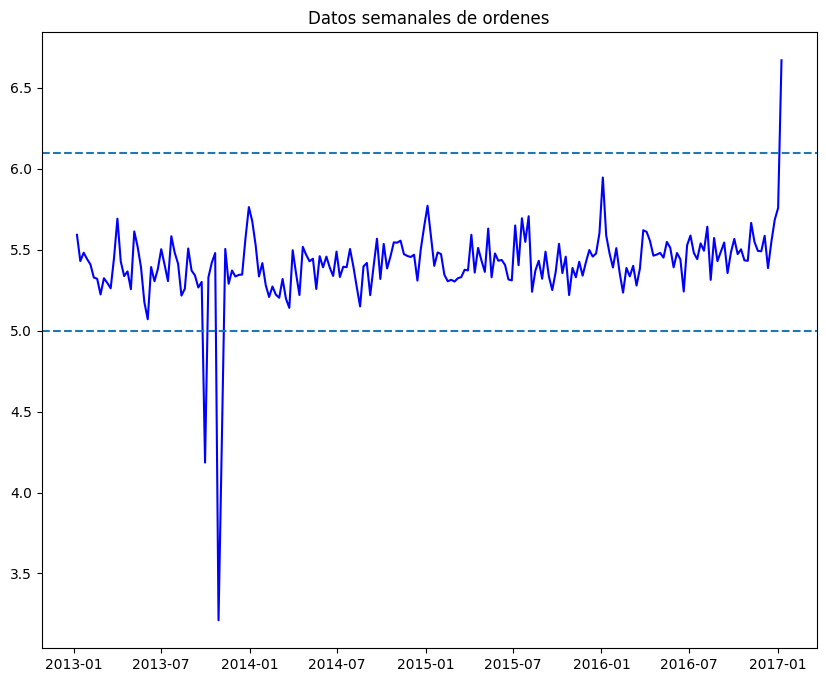

In [70]:
plt.figure(figsize=(10, 8))
plt.plot(y.index, y, label='Datos Originales', color='blue')
plt.axhline(5, ls='--')
plt.axhline(6.1, ls='--')
plt.title('Datos semanales de ordenes')
plt.show()

🔎 **Análisis gráfico.**

- Lo más interesante de nuestros datos es que estos se mantienen dentro de un rango en general constante entre las lineas doteadas entre los valores  5 y 6.

- Es notorio que existen datos entre la segunda mitad de 2013 y el inicio de 2014 con valores muy por debajo de los observados como tendencia general.

- Además también al final de nuestros datos se encuentra el pico máximo de los datos que también se dispara por encima de los demás datos

🎓 **Conclusión**:

- Lo primero será revisar los datos que cumplan la condicion que sean mayores o menores que los rangos mencionados anteriormente.
- Estos datos pueden ser considerados como outliers y podrian ser eliminados o en el caso contrario ser interpolados. -->


In [71]:
y[(y<=4.75) | (y>=6.3)]

Date
2013-09-30    4.185011
2013-10-28    3.210743
2013-11-04    4.337130
2017-01-09    6.670803
Name: Order_Demand_log, dtype: float64

🔥 **INSIGHT**
- Solo existen 4 puntos que se encuentran fuera de la tendencia general que se podrían considerar o como datos mal ingresados (con problemas) o outliers... por lo que estos los podría eliminar y no deberia afectar mucho a los datos pero como quiero tratar de no perder estos datos interpolaré estos primero eliminandolos y después interpolando linealmente


## Eliminación datos outliers

In [72]:
y_copia = y.copy()

y[(y < 4.60)  | (y>=6.3)] = np.nan


In [73]:

y = y.interpolate(method='linear')

## **Revisando los datos tratados e interpolados**

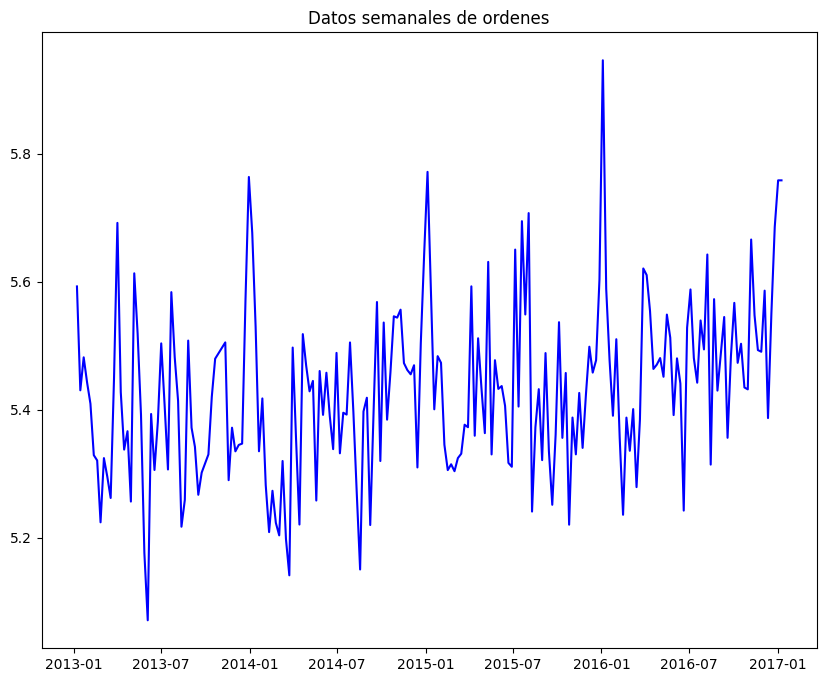

In [74]:
plt.figure(figsize=(10, 8))
plt.plot(y.index, y, label='Datos Originales', color='blue')
plt.title('Datos semanales de ordenes')
plt.show()

🔎 **Análisis gráfico.**

✅ Lo primero que es visible que nuestros datos han mejorado con respecto a los anteriores, se obsegva que la tendencia entre el 2013 y 2014 fue correjida y asi también la tendencia para el final de nuestros datos.

❓ Algo interesante y no bueno para nuestros datos es que al interpolar los datos el caracter creciente de nuestros datos se está perdiendo al final de nuestra seria debido que por la interpolación el dato es más bajo a diferencia de lo que vimos en el grafico anterior donde al final de nuestra serie habia un claro maximo

🎓 **Conclusión**:

Debido a lo mencionado anteriormente procedere a otorgar un valor más alto al ultimo dato de nuestra serie para poder conservar la tendencia creciente de nuestros datos.

In [75]:
y.sort_values(ascending=False)

Date
2016-01-04    5.946235
2015-01-05    5.771758
2013-12-30    5.763767
2017-01-09    5.758504
2017-01-02    5.758504
                ...   
2014-03-17    5.197869
2013-05-27    5.175905
2014-08-18    5.150052
2014-03-24    5.140918
2013-06-03    5.070622
Name: Order_Demand_log, Length: 210, dtype: float64

In [76]:
y[y.index=='2017-01-09'] = 6.1

# **FORECASTING MODELAJE**

## **Descomposición temporal**

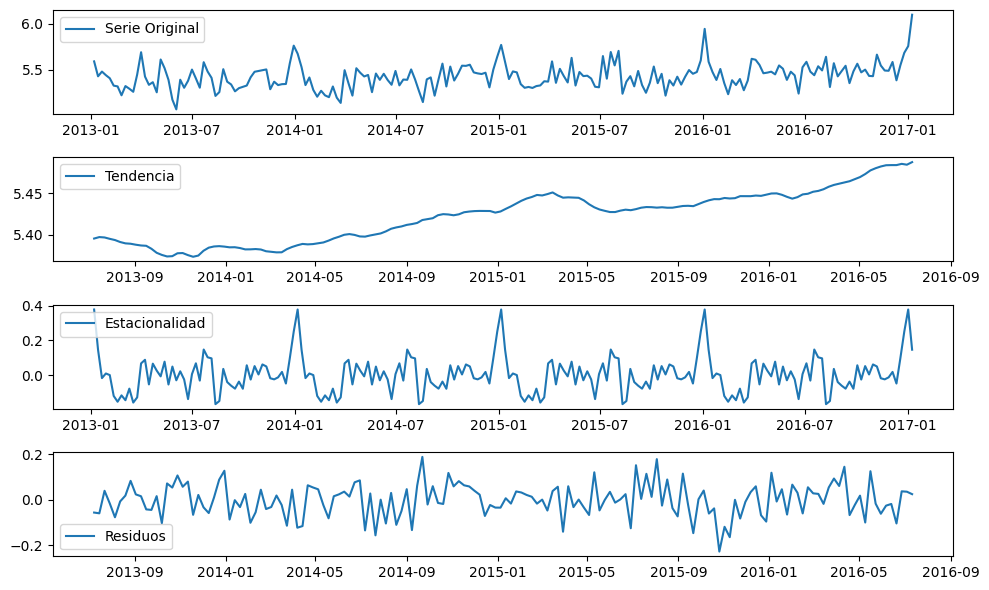

In [77]:
from statsmodels.tsa.seasonal import seasonal_decompose
result = seasonal_decompose(y, model='additive')

# Graficar los componentes
plt.figure(figsize=(10, 6))
plt.subplot(4, 1, 1)
plt.plot(y, label='Serie Original')
plt.legend()

plt.subplot(4, 1, 2)
plt.plot(result.trend, label='Tendencia')
plt.legend()

plt.subplot(4, 1, 3)
plt.plot(result.seasonal, label='Estacionalidad')
plt.legend()

plt.subplot(4, 1, 4)
plt.plot(result.resid, label='Residuos')
plt.legend()
plt.tight_layout()
plt.show()

🔎 **Análisis gráfico.**

- Lo primero que es notorio es que la tendencia es al alza sostenida desde 2014-01 hasta el 2015-04 donde disminuye y alcanza una meseta que progresivamente sigue aumentando hasta al final de nuestros datos
- Cada año se repite un patron ciclico en los datos donde siempre a principios de año hay un peak muy marcado de ordenes, lo que puede estar ligado algun tipo de promoción a fin de año. Posterior a esto bajan significativamente las ventas volviendo a tener un repunte significativamente mayor que el de principio de año y aún más variable. Considerando esto podemos considerar que cada 52 semanas hay un ciclo.

- Los residuos se encuentran bastante variables pero en general no dan signos más contundentes de seguir patrones pero lo que si se ve es heterocedasticidad.



🎓 **Conclusión**:

- ✅ **Serie con estacionalidad cada 52 semanas**

- ✅ **D = 1**

## **¿ Es la serie Estacionaria ?**

In [78]:
from statsmodels.tsa.stattools import adfuller

# Realizar el test de Dickey-Fuller
result = adfuller(y.values)
print('ADF Statistic:', result[0])
print('p-value:', result[1])
print('Critical Values:', result[4])

ADF Statistic: -6.0041649844955
p-value: 1.6304741192550954e-07
Critical Values: {'1%': -3.4621857592784546, '5%': -2.875537986778846, '10%': -2.574231080806213}


- Partimos de la $h_{o}:$ La serie no es estacionaria. Claramente en nuestro caso **rechazamos la hipotesis nula** y nuestra serie es *estacionaria*

🎓 **Conclusión**:

- ✅ **Serie estacionaria**

- ✅ **d = 0**

## **Graficos ACF Y PACF**

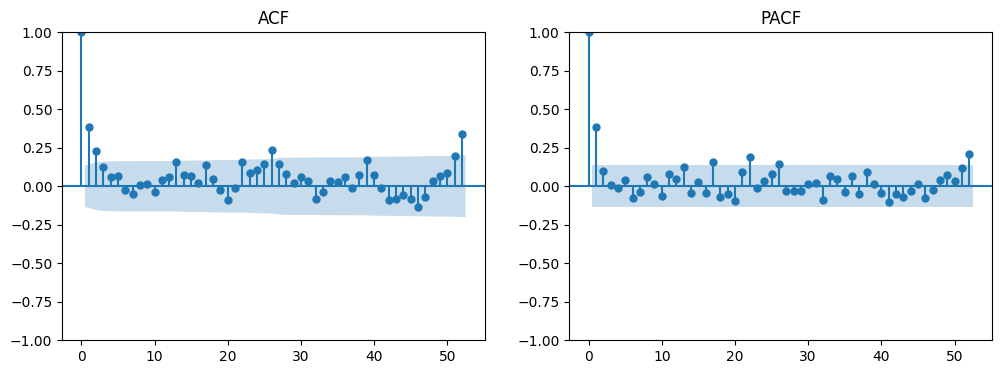

In [79]:
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.stattools import acf
from statsmodels.graphics.tsaplots import plot_pacf

fig, ax = plt.subplots(1, 2, figsize=(12, 4))  # opcional: ajustar tamaño
plot_acf(y,  title="ACF", lags=52, ax=ax[0])
plot_pacf(y, title="PACF", lags=52, ax=ax[1])
plt.show()

🔎 **Análisis gráfico.**

#### **ACF (q)**

Lo primero es entender que el gráfico `ACF` mide la correlación entre los diferentes valores de la serie en sus diferentes retardos. Es útil para identificar patrones de tipo MA (media móvil). En pocas palabras mide que tanto influye en los diferentes retados los retardos pasados.

En nuestro caso se ve que tenemos diferentes LAGS que son significativos y además se puede ver un cierto patrón oscilatorio.



#### **PACF (p)**

PACF mide la correlación directa entre LAGS "eliminando" la influencia que ejercen los lags intermedios.  Util para saber la componente AR. 

Similar al anterior gráfico se puede observar que existen varios LAGS significativos y sin un patron claro.


🎓 **Conclusión**:

- Lo primero claro es que debido a que en ambos graficos se encuentran lags significativos $q$ y $p$ $>>$ 0
- Del gráfico ACF se observa que los valores pasados tienen influencia en los valores actuales
- El patron oscilatorio nos informa sobre una variable sin considerar hasta el momento que es la precensia de estacionalidad o de una estructura más compleja
- A diferencia del ACF en el PACF no se observan patrones claros ni un corte marcado destacando la falta de decaimiento en ambos gráficos.

✅ No es un proceso puramente aleatoreo y se confirma la dependencia estacional

✅ p y q son mayores que cero

✅ La presencia de estos lags significativos indica que la serie no está completamente diferenciada o en el caso que el test dickey fuller diga lo contrario entonces nos indica de un patron probablmente más estacional por lo que el uso de **SARIMA** estaría más que justificado

### **TEST  Dickey-Fuller sugiere que ya serie está diferenciada pero los gráficos dicen que no?**

🔥 **INSIGHT** 

Según el test Dickey-fuller dice que nuestra serie ya es estacionaria pero nuestros graficos con tantos LAGS significativos dice que falta aplicar más diferenciación debido a la estacionalidad que tienen nuestros datos.
Entonces el test nos dice que la tendencia es estacionaria y nuestros graficos nos dicen que la serie tiene que ser diferenciada estacionalmente para eliminar la dependencia de los lags con sus rezagos


🎓 **Conclusión**:

- ✅ Modelo elegido SARIMA

- ✅ D > 0

# **IMPLEMENTANDO SARIMA**

In [80]:
import statsmodels.api as sm

model = sm.tsa.SARIMAX(y, order=(1, 0, 1), seasonal_order= (0, 1, 0, 52))
results = model.fit()
print(results.summary())

# Pronóstico para los próximos 'n' pasos
n_pronostico = 52 # Ejemplo: pronóstico para las próximas 52 semanas
pronostico_sarima = results.get_forecast(steps=n_pronostico)
pronostico_intervalo = pronostico_sarima.conf_int()


                                      SARIMAX Results                                      
Dep. Variable:                    Order_Demand_log   No. Observations:                  210
Model:             SARIMAX(1, 0, 1)x(0, 1, [], 52)   Log Likelihood                  87.939
Date:                             Tue, 01 Apr 2025   AIC                           -169.879
Time:                                     18:42:05   BIC                           -160.691
Sample:                                 01-07-2013   HQIC                          -166.147
                                      - 01-09-2017                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9522      0.048     19.771      0.000       0.858       1.047
ma.L1         -0.8674      

:pushpin:

### **Ljung-Box**:

Mide si los residuos están o no correlacionados (patrones que el modelo no ha capturado)

$H_{0}$: **los residuos NO están autocorrelacionados**. En nuestro caso la **Prob(Q)** es de 0.18 que es mayor que nuestro p_value no tenemos información suficiente para rechazar la hipotesis nula por lo que la aceptamos

✔️ Residuos no correlacionados

### **Jarque-Bera (JB)**

Permite conocer si los residuos tienen una distribución normal (necesario para que nuestros residuos sean ruido blanco)


$H_{0}$: **Los residuos son normalmente distribuidos.**.

En nuestro caso **Prob(JB)** $<$ **p_value** por lo que **rechazamos** la hipotesis nula

✖️ Los residuos no estan normalmente distribuidos

### **Heteroskedasticity (H)**

Evalua si la varianza de los residuos es constante 

$H_{0}$: **Varianza constante**.

En nuestro caso **Prob(H)** $>$ **p_value** por lo que la varianza de los residuos es constante


✔️ La varianza de nuestros residuos son costante


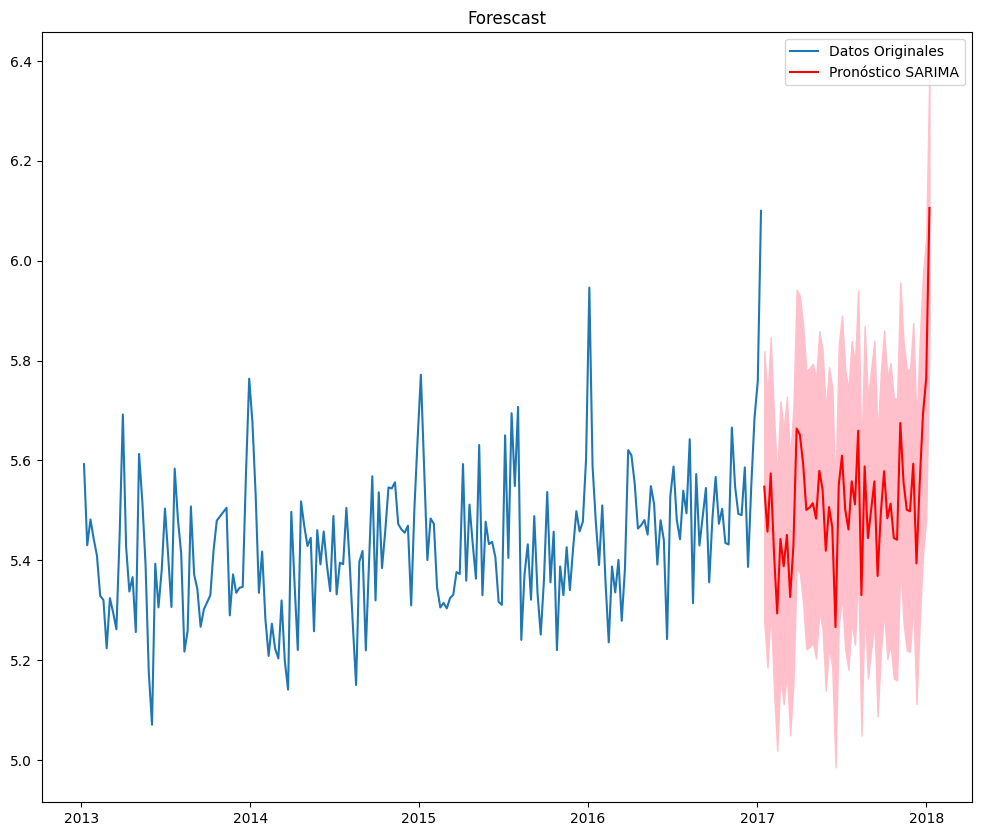

In [81]:

import matplotlib.pyplot as plt
plt.figure(figsize=(12, 10))
plt.plot(y, label='Datos Originales')
plt.plot(pronostico_sarima.predicted_mean, color='red', label='Pronóstico SARIMA')
plt.fill_between(pronostico_intervalo.index, pronostico_intervalo.iloc[:, 0], pronostico_intervalo.iloc[:, 1], color='pink')
plt.title('Forescast')
plt.legend()
plt.show()

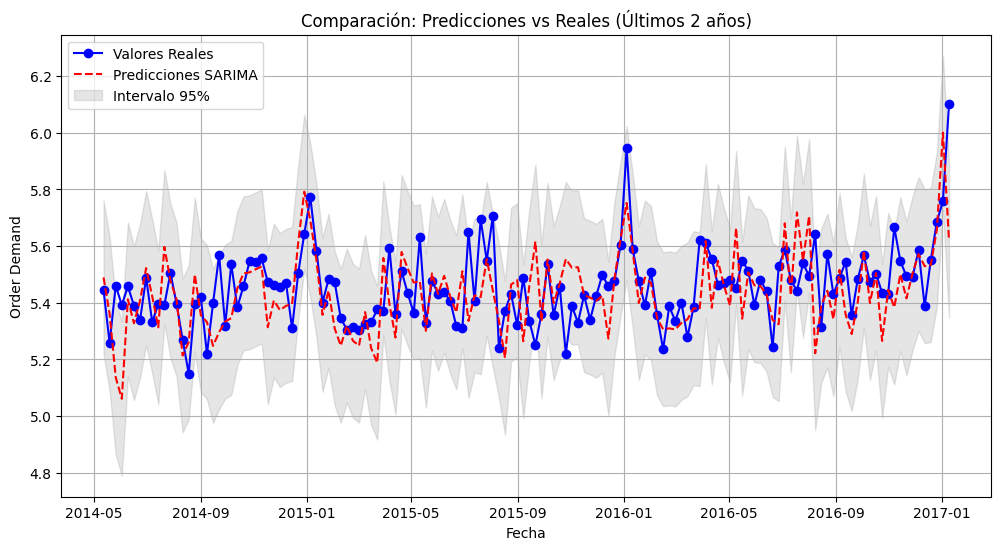

In [82]:

start_date = y.index[70]  
end_date = y.index[-1]  


predictions = results.get_prediction(
    start=start_date, 
    end=end_date, 
    dynamic=False 
)

# Extraer valores predichos y reales
predichos = predictions.predicted_mean
reales = y.loc[start_date:end_date]
intervalos = predictions.conf_int()


plt.figure(figsize=(12, 6))

# Graficar datos reales
plt.plot(reales, label='Valores Reales', color='blue', marker='o')

# Graficar predicciones
plt.plot(predichos, label='Predicciones SARIMA', color='red', linestyle='--')

# Rellenar intervalo de confianza
plt.fill_between(
    intervalos.index,
    intervalos.iloc[:, 0],
    intervalos.iloc[:, 1],
    color='gray',
    alpha=0.2,
    label='Intervalo 95%'
)

plt.title('Comparación: Predicciones vs Reales (Últimos 2 años)')
plt.xlabel('Fecha')
plt.ylabel('Order Demand')
plt.legend()
plt.grid(True)
plt.show()



🔎 **Análisis gráfico.**

Como es de esperar no necesariamente los datos de nuestras predicciones sigue fielmente los datos reales pero podemos ver en los intervalos de confianza que capta de manera perfecta nuestra tendencia en los datos sin dejar fuera de estos a ninguno de nuestros datos. Por lo tanto el modelo está pudiendo capturar correctamente la tendencia general y la estacionalidad de los datos.




MAE: 24.30
RMSE: 34.76


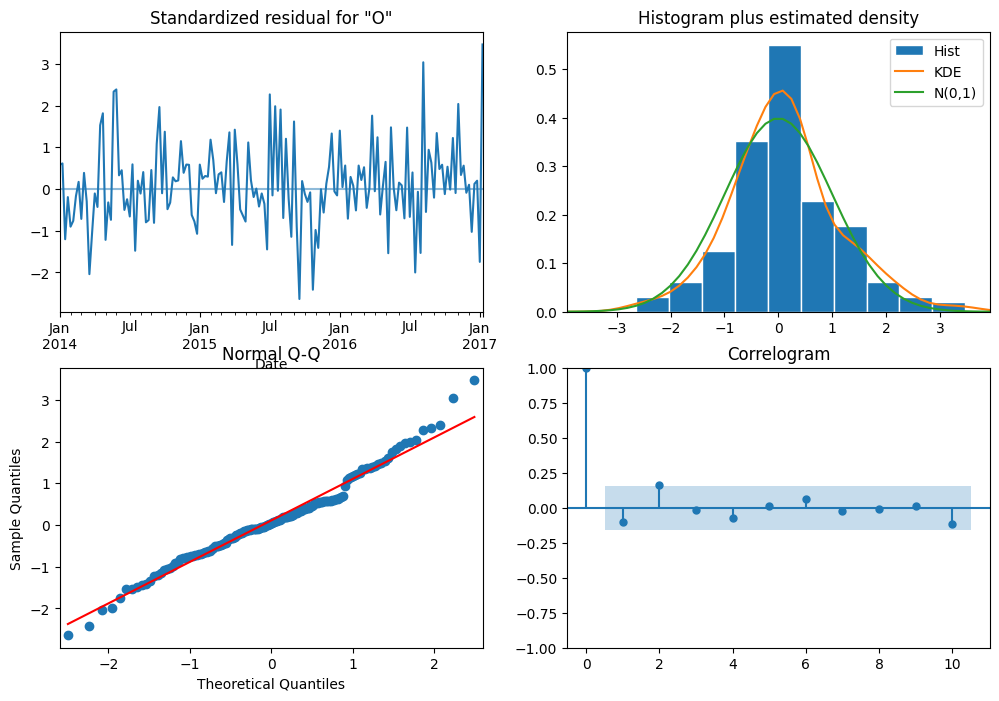

In [ ]:

results.plot_diagnostics(figsize=(12, 8))
plt.show()

🔎 **Análisis gráfico.**

#### _Residuos standarizados_
- En general los residuos fluctuan cercano al cero lo que es bueno. No hay un patron claro aunque se podria pensar un patron de abanico (heterostacidad) esta la descartamos de plano porque no hay evidencia significativa segun Heteroskedasticity (H).



### _Histograma_
- El histograma se ve que se asemeja bastante a la de una distribución normal unque con una inclinación de su moda levemente a la derecha y sus colas se ven desviadas lo que sugiere colas más pesadas o ligeras que una normal. Además la prueba Jarque-Bera (JB)
confirma que nuestros residuos no siguen una distribución normal.

### _QQ- PLOT_
- La mayor parte de los puntos se alinea a la linea teórica aunque cerca de los cuantiles -2 y de 1 añ 2 estos se van separando progresivamente. Esto sugiere que las colas de la distribución pueden ser más pesadas o ligeras que una distribución normal. El patron de la cola derecha sugiere una distribución sesgada positivamente, lo que podría indicar que el modelo subestima eventos extremos positivos



### _Correlograma_
- En el LAG 2 se observan valores significativos lo que nos permite observar que aún existe una autocorrelación significativa en esos lags y que no hemos podido eliminar con esta configuración de SARIMA que no ha podido capturar toda la estructura temporal de los datos. Los demas LAGS se encuentran dentro de los intervalos de confianza lo que es bueno. Ahora es contradictorio nuestra observación porque según la prueba  Ljung-Box no hay autocorrelación significativa en los residuos.


🎓 **Conclusión**:


Debido a las evidencias tanto del gráfico de residuos además de los estadisticos del modelos se puede concluir que si bien el modelo se comporta de buena forma tiene espacio a mejora debido a que aún tenemos un LAG significativo en nuestros residuos lo que nos indica que todavia se pueden realizar mejoras a este modelo.

- Si bien tenemos que en el LAG 2 hay un autocorrelacion significativa según la prueba estadistica esta no es significativa estadisticamente por lo que podriamos dejar el modelo tal cual incluso.

- Ajustar los parámetros de SARIMA



# **USANDO PMDARIMA**

In [84]:

subset = len(y)*3//4
train = y.iloc[:subset]
test = y.iloc[subset:]

In [ ]:
from pmdarima import auto_arima
import warnings

warnings.filterwarnings("ignore", category=FutureWarning, module="sklearn.utils.deprecation")

auto_model = auto_arima(
    train,
    start_p=0, start_q=0,
    max_p=3, max_q=3,
    seasonal=True,
    m=52,  # frecuencia semanal
    start_P=0, start_Q=0,
    max_P=2, max_Q=2,
    d=None, D=1,
    trace=True,
    error_action='ignore',
    suppress_warnings=True,
    stepwise=True
)

print(auto_model.summary())

Performing stepwise search to minimize aic
 ARIMA(0,0,0)(0,1,0)[52] intercept   : AIC=-114.656, Time=0.31 sec
 ARIMA(1,0,0)(1,1,0)[52] intercept   : AIC=-123.809, Time=19.43 sec
 ARIMA(0,0,1)(0,1,1)[52] intercept   : AIC=-122.934, Time=8.72 sec
 ARIMA(0,0,0)(0,1,0)[52]             : AIC=-114.714, Time=0.12 sec
 ARIMA(1,0,0)(0,1,0)[52] intercept   : AIC=-115.180, Time=0.44 sec
 ARIMA(1,0,0)(2,1,0)[52] intercept   : AIC=inf, Time=49.02 sec
 ARIMA(1,0,0)(1,1,1)[52] intercept   : AIC=inf, Time=33.72 sec
 ARIMA(1,0,0)(0,1,1)[52] intercept   : AIC=-123.224, Time=9.76 sec
 ARIMA(1,0,0)(2,1,1)[52] intercept   : AIC=-120.991, Time=52.87 sec
 ARIMA(0,0,0)(1,1,0)[52] intercept   : AIC=-124.486, Time=7.46 sec
 ARIMA(0,0,0)(2,1,0)[52] intercept   : AIC=inf, Time=40.95 sec
 ARIMA(0,0,0)(1,1,1)[52] intercept   : AIC=inf, Time=26.46 sec
 ARIMA(0,0,0)(0,1,1)[52] intercept   : AIC=-123.803, Time=6.05 sec
 ARIMA(0,0,0)(2,1,1)[52] intercept   : AIC=-121.699, Time=36.48 sec
 ARIMA(0,0,1)(1,1,0)[52] interce

                                SARIMAX Results                                 
Dep. Variable:         Order_Demand_log   No. Observations:                  157
Model:             SARIMAX(1, 1, 0, 52)   Log Likelihood                  63.460
Date:                  Tue, 01 Apr 2025   AIC                           -122.921
Time:                          18:43:01   BIC                           -117.613
Sample:                      01-07-2013   HQIC                          -120.770
                           - 01-04-2016                                         
Covariance Type:                    opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.S.L52      -0.4203      0.120     -3.498      0.000      -0.656      -0.185
sigma2         0.0159      0.003      6.046      0.000       0.011       0.021
Ljung-Box (L1) (Q):                 

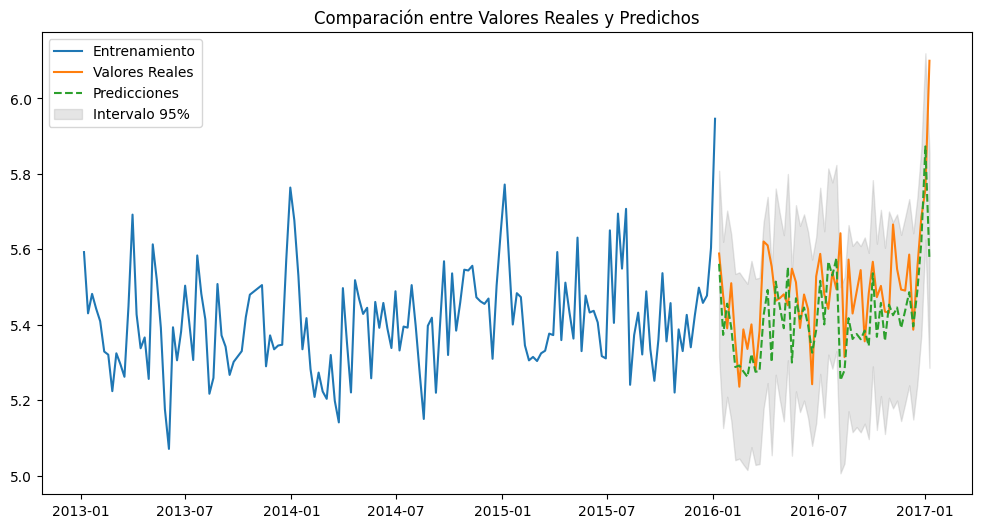

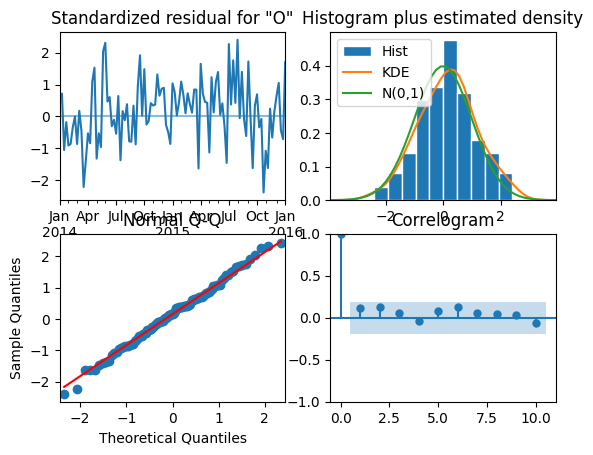

In [86]:


model = sm.tsa.SARIMAX(train, order=(0, 0, 0), seasonal_order=(1,1, 0, 52))
results = model.fit()
print(results.summary())

# Obtener predicciones para el período de prueba
forecast = results.get_forecast(steps=len(test))
forecast_mean = forecast.predicted_mean

import matplotlib.pyplot as plt

intervalos = forecast.conf_int()

plt.figure(figsize=(12, 6))
plt.plot(train.index, train, label='Entrenamiento')
plt.plot(test.index, test, label='Valores Reales')
plt.plot(test.index, forecast_mean, label='Predicciones', linestyle='--')
plt.title('Comparación entre Valores Reales y Predichos')
plt.fill_between(
    intervalos.index,
    intervalos.iloc[:, 0],
    intervalos.iloc[:, 1],
    color='gray',
    alpha=0.2,
    label='Intervalo 95%'
)
plt.legend()
plt.show()



results.plot_diagnostics()
plt.show()



In [ ]:
from sklearn.metrics import mean_squared_error

test_original = np.expm1(test)
forecast_original = np.expm1(forecast_mean)

# Calcular MSE y RMSE en escala original
mse = mean_squared_error(test_original, forecast_original)
rmse = np.sqrt(mse)

print(f'MSE: {mse:.2f}')
print(f'RMSE: {rmse:.2f}')

MSE: 1400.88
RMSE: 37.43
